In [ ]:
!sudo apt-get -qq install -y fonts-nanum > /dev/null

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 한글 폰트 적용
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
print(f"사용 장치: {device}")

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
사용 장치: cuda


In [ ]:
from google.colab import drive
import zipfile
import os

# 1. 구글 드라이브 마운트 (연동)
drive.mount('/content/drive')

# 2. 코랩이 허용하는 안전한 경로에 폴더 생성
real_kaggle_dir = '/content/kaggle/input/ai12-level1-project'
os.makedirs(real_kaggle_dir, exist_ok=True)

# 3. 루트(/) 경로에 가짜 지름길(심볼릭 링크) 생성
!ln -s /content/kaggle /kaggle 2>/dev/null || true

# 4. 첫 번째 zip 압축 해제
drive_zip_path = '/content/drive/MyDrive/export_shared_clean[1,3].zip'
print("📦 첫 번째 데이터셋 압축 해제 시작...")
with zipfile.ZipFile(drive_zip_path, 'r') as zip_ref:
    zip_ref.extractall(real_kaggle_dir)
    print("🎯 완료!")

# 5. 두 번째 zip 압축 해제 (여기서 drive_zip_path2를 써야 함!)
drive_zip_path2 = '/content/drive/MyDrive/ai12-level1-project.zip'
print("📦 두 번째 데이터셋 압축 해제 시작...")
with zipfile.ZipFile(drive_zip_path2, 'r') as zip_ref:   # ⚠️ 여기 drive_zip_path -> drive_zip_path2 로 수정
    zip_ref.extractall(real_kaggle_dir)
    print("🎯 완료! 두 데이터셋이 모두 같은 폴더에 합쳐졌습니다.")

Mounted at /content/drive
📦 첫 번째 데이터셋 압축 해제 시작...
🎯 완료!
📦 두 번째 데이터셋 압축 해제 시작...
🎯 완료! 두 데이터셋이 모두 같은 폴더에 합쳐졌습니다.


In [ ]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 1. 데이터 경로 설정 (앞서 심볼릭 링크로 뚫어놓은 캐글 가상 경로 활용)
image_dir = '/content/kaggle/input/ai12-level1-project/export_shared_clean/images/train'

image_data = []
supported_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.JPEG', '.PNG')

# 2. 200개 이미지 전수조사 (크기 및 비율 추출)
print("🔍 이미지 데이터셋 분석 중...")
for file_name in tqdm(os.listdir(image_dir)):
    if file_name.endswith(supported_extensions):
        file_path = os.path.join(image_dir, file_name)

        # 이미지 읽기 (OpenCV 활용)
        img = cv2.imread(file_path)
        if img is not None:
            height, width, channels = img.shape
            aspect_ratio = width / height

            image_data.append({
                'file_name': file_name,
                'width': width,
                'height': height,
                'ratio': aspect_ratio,
                'pixels': width * height
            })

# 데이터프레임 변환
df = pd.DataFrame(image_data)

# 3. 통계치 요약 출력 (발표 장표 텍스트용)
print("\n=== 📈 이미지 크기 통계 요약 ===")
print(df[['width', 'height', 'ratio']].describe())



🔍 이미지 데이터셋 분석 중...


100%|██████████| 2856/2856 [02:01<00:00, 23.44it/s]


=== 📈 이미지 크기 통계 요약 ===
        width  height         ratio
count  2856.0  2856.0  2.856000e+03
mean    976.0  1280.0  7.625000e-01
std       0.0     0.0  1.943231e-14
min     976.0  1280.0  7.625000e-01
25%     976.0  1280.0  7.625000e-01
50%     976.0  1280.0  7.625000e-01
75%     976.0  1280.0  7.625000e-01
max     976.0  1280.0  7.625000e-01


이미지의 크기가 커서 비율에 맞춰서 줄이고 개수가 적기에 여러가지 증강을 도입합니다

In [ ]:
import os
import json
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import tv_tensors


class PillDatasetDETR(Dataset):
    def __init__(self, image_dirs, single_json_path, transform=None,
                 allowed_category_ids=None, drop_empty_images=True):
        """
        image_dirs: str 하나 또는 여러 이미지 폴더 리스트
        single_json_path: 기존+새 데이터가 전부 합쳐진 통합 COCO json 경로
        allowed_category_ids: None이면 전체 클래스 사용, set이면 그 클래스만 남김
        drop_empty_images: allowed_category_ids 필터링 후 박스가 0개인 이미지는 제외
        """
        self.image_dirs = [image_dirs] if isinstance(image_dirs, str) else list(image_dirs)
        self.single_json_path = single_json_path
        self.transform = transform
        self.allowed_category_ids = allowed_category_ids
        self.drop_empty_images = drop_empty_images

        # 여러 폴더에서 이미지 목록 수집 (파일명 -> 실제 경로)
        self.image_index = {}
        for d in self.image_dirs:
            for f in os.listdir(d):
                if f.endswith(".png"):
                    self.image_index[f] = os.path.join(d, f)
        self.image_files = sorted(self.image_index.keys())

        self.class_map = {}
        self.single_json_annotations = {}  # base(파일명, 확장자 제외) -> [ann, ann, ...]

        self._load_single_json()
        self._build_class_map()

        if self.allowed_category_ids is not None and self.drop_empty_images:
            self.image_files = [
                f for f in self.image_files
                if len(self._get_annotations(f)) > 0
            ]
            print(f"필터링 후 남은 이미지 수: {len(self.image_files)}")

    def _load_single_json(self):
        with open(self.single_json_path, encoding="utf-8") as f:
            data = json.load(f)

        # file_name이 "images/train/xxx.png" 처럼 하위 경로를 포함할 수 있으므로 basename만 사용
        id_to_filename = {img["id"]: os.path.basename(img["file_name"]) for img in data["images"]}

        for ann in data["annotations"]:
            file_name = id_to_filename.get(ann["image_id"])
            if file_name is None:
                continue
            base = os.path.splitext(file_name)[0]
            self.single_json_annotations.setdefault(base, []).append(ann)

    def _build_class_map(self):
        category_ids = set()
        for anns in self.single_json_annotations.values():
            for ann in anns:
                category_ids.add(ann["category_id"])

        if self.allowed_category_ids is not None:
            category_ids &= self.allowed_category_ids

        self.class_map = {cid: idx for idx, cid in enumerate(sorted(category_ids))}
        print(f"✅ 총 인식된 알약 클래스 개수 : {len(self.class_map)}")

    def __len__(self):
        return len(self.image_files)

    def _get_annotations(self, img_name):
        base = os.path.splitext(img_name)[0]
        anns = self.single_json_annotations.get(base, [])
        if self.allowed_category_ids is not None:
            anns = [a for a in anns if a["category_id"] in self.allowed_category_ids]
        return anns

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = self.image_index[img_name]
        image = Image.open(img_path).convert("RGB")
        width, height = image.size

        anns = self._get_annotations(img_name)

        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(self.class_map[ann["category_id"]])

        boxes = torch.tensor(boxes, dtype=torch.float32) if len(boxes) > 0 else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(height, width)),
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        if self.transform:
            image, target = self.transform(image, target)
            boxes, labels = target["boxes"], target["labels"]
            if len(boxes) > 0:
                valid = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
                boxes, labels = boxes[valid], labels[valid]

        new_w, new_h = (image.shape[2], image.shape[1]) if isinstance(image, torch.Tensor) else image.size

        if len(boxes) > 0:
            cx = (boxes[:, 0] + boxes[:, 2]) / 2.0
            cy = (boxes[:, 1] + boxes[:, 3]) / 2.0
            bw = boxes[:, 2] - boxes[:, 0]
            bh = boxes[:, 3] - boxes[:, 1]
            boxes_norm = torch.stack([cx / new_w, cy / new_h, bw / new_w, bh / new_h], dim=-1)
        else:
            boxes_norm = torch.zeros((0, 4), dtype=torch.float32)

        target["boxes"] = boxes_norm
        target["class_labels"] = labels

        return image, target


def collate_fn(batch):
    images, targets = tuple(zip(*batch))
    pixel_values = torch.stack(images)
    return pixel_values, list(targets)

In [ ]:
import os, json, math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


# ---------------------------------------------------------
# 1) 어노테이션 인덱스 구축 (통합 json 기반)
# ---------------------------------------------------------
def build_annotation_index(single_json_path, label_dir=None):
    """
    single_json_path: 기존+새 데이터가 전부 합쳐진 통합 COCO json 경로 (이제 이거 하나면 충분)
    label_dir: 레거시 폴더별 json 방식 (지금은 안 씀. 나중에 별도 데이터가 또 생기면 대비용)
             ⚠️ single_json_path에 이미 기존 데이터가 포함돼 있다면 label_dir은 절대 같이 넣지 마세요.
                같은 이미지 annotation이 중복으로 쌓입니다.

    반환값: {base_filename(확장자 제외): [ {"bbox":..., "category_id":..., "source":...}, ... ]}
    """
    index = {}
    category_names = {}  # category_id -> name

    # --- 통합 json (COCO 스타일) ---
    with open(single_json_path, encoding="utf-8") as f:
        data = json.load(f)

    for cat in data.get("categories", []):
        category_names[cat["id"]] = cat["name"]

    id_to_filename = {
        img["id"]: os.path.basename(img["file_name"]) for img in data["images"]
    }

    for ann in data["annotations"]:
        file_name = id_to_filename.get(ann["image_id"])
        if file_name is None:
            continue
        base = os.path.splitext(file_name)[0]
        index.setdefault(base, []).append({
            "bbox": ann["bbox"],
            "category_id": ann["category_id"],
            "source": {
                "type": "single_json",
                "json_path": single_json_path,
                "image_id": ann["image_id"],
            },
        })

    # --- (레거시) 폴더별 json 방식 - 지금은 안 쓰지만 옵션으로 남겨둠 ---
    if label_dir is not None:
        ann_folder_map = {}
        for folder in os.listdir(label_dir):
            if folder.endswith("_json"):
                ann_folder_map[folder.replace("_json", "")] = os.path.join(label_dir, folder)

        for ann_root in ann_folder_map.values():
            for drug in os.listdir(ann_root):
                drug_path = os.path.join(ann_root, drug)
                if not os.path.isdir(drug_path):
                    continue
                for file in os.listdir(drug_path):
                    if not file.endswith(".json"):
                        continue
                    json_path = os.path.join(drug_path, file)
                    with open(json_path, encoding="utf-8") as f:
                        fdata = json.load(f)

                    for cat in fdata.get("categories", []):
                        category_names[cat["id"]] = cat["name"]

                    base = os.path.splitext(file)[0]
                    for ann in fdata["annotations"]:
                        index.setdefault(base, []).append({
                            "bbox": ann["bbox"],
                            "category_id": ann["category_id"],
                            "source": {"type": "folder", "json_path": json_path},
                        })

    return index, category_names


def get_image_annotations(img_name, ann_index):
    """해당 이미지의 모든 박스를 원본 좌표(x,y,w,h)로 가져오기"""
    base = os.path.splitext(img_name)[0]
    return ann_index.get(base, [])


# ---------------------------------------------------------
# 2) 이미지 한 장 + 박스 + (선택) 관련 어노테이션 보기
# ---------------------------------------------------------
def show_image_with_boxes(img_name, image_dir, ann_index, category_names=None,
                           figsize=(7, 9), show_json=True):
    image = Image.open(os.path.join(image_dir, img_name)).convert("RGB")
    boxes = get_image_annotations(img_name, ann_index)
    category_names = category_names or {}

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.set_title(f"{img_name}  (박스 {len(boxes)}개)")

    for i, b in enumerate(boxes):
        x, y, w, h = b["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        name = category_names.get(b["category_id"], "")
        label = f"#{i} cat={b['category_id']}" + (f" ({name})" if name else "")
        ax.text(x, max(y - 5, 0), label,
                 color="white", fontsize=9, backgroundcolor="red")
    ax.axis("off")
    plt.show()

    if show_json:
        print(f"\n📄 관련 어노테이션 ({len(boxes)}개):")
        seen_folder_json = set()

        for b in boxes:
            src = b["source"]
            if src["type"] == "folder":
                if src["json_path"] in seen_folder_json:
                    continue
                seen_folder_json.add(src["json_path"])
                print(f"\n--- (폴더 방식) {src['json_path']} ---")
                with open(src["json_path"], encoding="utf-8") as f:
                    print(json.dumps(json.load(f), ensure_ascii=False, indent=2))
            else:
                print(f"\n--- (통합 json) {src['json_path']} | image_id={src['image_id']} ---")
                print(json.dumps({
                    "bbox": b["bbox"],
                    "category_id": b["category_id"],
                    "category_name": category_names.get(b["category_id"], ""),
                }, ensure_ascii=False, indent=2))

    return boxes


# ---------------------------------------------------------
# 3) 여러 장 그리드로 훑어보기
# ---------------------------------------------------------
def browse_grid(image_files, image_dirs, ann_index, start=0, num=9, cols=3):
    """
    image_dirs: 폴더 하나(str) 또는 여러 폴더(list)
    """
    if isinstance(image_dirs, str):
        image_dirs = [image_dirs]

    def find_image_path(img_name):
        for d in image_dirs:
            p = os.path.join(d, img_name)
            if os.path.exists(p):
                return p
        return None

    rows = math.ceil(num / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 6))
    axes = axes.flatten()

    for i in range(num):
        idx = start + i
        if idx >= len(image_files):
            axes[i].axis("off")
            continue
        img_name = image_files[idx]
        img_path = find_image_path(img_name)

        ax = axes[i]
        if img_path is None:
            ax.set_title(f"[{idx}] {img_name}\n(파일 못 찾음)", fontsize=8, color="red")
            ax.axis("off")
            continue

        image = Image.open(img_path).convert("RGB")
        boxes = get_image_annotations(img_name, ann_index)

        ax.imshow(image)
        ax.set_title(f"[{idx}] {img_name} ({len(boxes)}개)", fontsize=8)
        for b in boxes:
            x, y, w, h = b["bbox"]
            ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5,
                                            edgecolor="red", facecolor="none"))
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
import os
import torch
from torchvision.transforms import v2
from torch.utils.data import DataLoader
from PIL import Image
from torch.utils.data import Dataset

# ==========================================
# 1. 사이즈 및 트랜스폼 정의 (기존 내용 유지)
# ==========================================
IMAGE_SIZE = (1280, 992)

train_transform = v2.Compose([
    v2.ToImage(),

    v2.RandomChoice([
        v2.RandomZoomOut(fill=0, side_range=(1.0, 1.3)),
        v2.RandomIoUCrop(),
        v2.Identity(),
    ]),

    v2.Resize(IMAGE_SIZE),
    v2.RandomHorizontalFlip(0.5),

    v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.5, 1.5))], p=0.3),
    v2.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),

    v2.ColorJitter(brightness=0.15, contrast=0.25, saturation=0.05, hue=0),

    v2.SanitizeBoundingBoxes(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize(IMAGE_SIZE),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. 경로 정의
# ==========================================
TRAIN_IMG_DIR = '/content/kaggle/input/ai12-level1-project/export_shared_clean/images/train'
TRAIN_JSON = '/content/kaggle/input/ai12-level1-project/export_shared_clean/train.json'

TEST_IMG_DIR = '/content/kaggle/input/ai12-level1-project/sprint_ai_project1_data/test_images'

VAL_IMG_DIR = '/content/kaggle/input/ai12-level1-project/export_shared_clean/images/val'
VAL_JSON = '/content/kaggle/input/ai12-level1-project/export_shared_clean/val.json'


# ==========================================
# 3. 라벨 없는 test 전용 데이터셋
# ==========================================
class PillTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        image = Image.open(os.path.join(self.image_dir, img_name)).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_name


# ==========================================
# 4. Train / Val 데이터셋
# ==========================================
train_dataset = PillDatasetDETR(
    image_dirs=TRAIN_IMG_DIR,
    single_json_path=TRAIN_JSON,
    transform=train_transform,
    allowed_category_ids=None,
)

val_dataset = PillDatasetDETR(
    image_dirs=VAL_IMG_DIR,
    single_json_path=VAL_JSON,
    transform=test_transform,
    allowed_category_ids=None,
)

# --------------------------------------------------------
# class_map 정합성 확인 (에러 대신 진단만, train 기준으로 강제 통일)
# --------------------------------------------------------
train_only = set(train_dataset.class_map.keys()) - set(val_dataset.class_map.keys())
val_only = set(val_dataset.class_map.keys()) - set(train_dataset.class_map.keys())

print(f"train에만 있는 클래스: {len(train_only)}개")
print(f"val에만 있는 클래스: {len(val_only)}개  -> {val_only if val_only else '없음'}")

if val_only:
    print("⚠️ val에만 있는 클래스가 있습니다. 이 클래스가 찍힌 val 이미지의 박스는 무시됩니다.")

# ⚠️ 핵심: val의 class_map을 train 기준으로 강제 통일 (인덱스 번호를 맞춰야 함)
val_dataset.class_map = train_dataset.class_map


# ==========================================
# 5. 로더(DataLoader) 생성
# ==========================================
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

test_dataset = PillTestDataset(TEST_IMG_DIR, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

print("\n==================================================")
print(f"✅ 학습 데이터(Train) 로드: {len(train_dataset)}장 (증강 O)")
print(f"✅ 검증 데이터(Valid) 로드: {len(val_dataset)}장 (증강 X)")
print(f"✅ 테스트 데이터(Test) 로드: {len(test_dataset)}장 (증강 X, 라벨 X)")
print(f"✅ 전체 클래스 수: {len(train_dataset.class_map)}")
print("==================================================")

✅ 총 인식된 알약 클래스 개수 : 91
✅ 총 인식된 알약 클래스 개수 : 35
train에만 있는 클래스: 56개
val에만 있는 클래스: 0개  -> 없음

✅ 학습 데이터(Train) 로드: 2856장 (증강 O)
✅ 검증 데이터(Valid) 로드: 45장 (증강 X)
✅ 테스트 데이터(Test) 로드: 842장 (증강 X, 라벨 X)
✅ 전체 클래스 수: 91


여기전까지는 사실상 고정!(물론 증강부분은 변하겠지만) 이상한 이미지 뺴는 역할이었어요 여기 다음은 새로운 기법인 이미지 복사해서 늘리기

이건 배경 이미지 준비

지금부터 모델입니다

In [ ]:
!pip install transformers

In [ ]:
from transformers import RTDetrForObjectDetection

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = len(train_dataset.class_map)
id2label = {idx: str(cat_id) for cat_id, idx in train_dataset.class_map.items()}
label2id = {v: k for k, v in id2label.items()}

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"  # 필요시 다른 체크포인트로 교체

model = RTDetrForObjectDetection.from_pretrained(
    CHECKPOINT,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(DEVICE)

model.config.num_queries = 100 # 기존에는 200개의 후보를잡는다면 너무많으니줄임

frozen_count = 0
for name, param in model.named_parameters():
    if "backbone" in name:
        if "encoder.stages.2" in name or "encoder.stages.3" in name:
            param.requires_grad = True   # 뒷단 2개 stage만 열기
        else:
            param.requires_grad = False  # embedder + stage 0,1은 얼림
    # backbone 아닌 부분(디코더, 헤드 등)은 기본적으로 True 유지되어 있을 것

# 확인
frozen = sum(1 for n, p in model.named_parameters() if "backbone" in n and not p.requires_grad)
unfrozen_backbone = sum(1 for n, p in model.named_parameters() if "backbone" in n and p.requires_grad)
print(f"백본 얼림: {frozen}개 / 백본 학습가능: {unfrozen_backbone}개")
print(f"✅ 모델 로드 완료: 클래스 {NUM_CLASSES}개")

config.json:   0%|          | 0.00/5.11k [00:00<?, ?B/s]

[transformers] You passed `num_labels=91` which is incompatible to the `id2label` map of length `80`.


model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd_coco_o365
Key                                                 | Status   |                                                                                         
----------------------------------------------------+----------+-----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([91, 256])
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([92, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([91])          
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([91

백본 얼림: 26개 / 백본 학습가능: 29개
✅ 모델 로드 완료: 클래스 91개


In [ ]:
stage_names = set()
for name, _ in model.named_parameters():
    if "encoder.stages." in name:
        stage_num = name.split("encoder.stages.")[1].split(".")[0]
        stage_names.add(stage_num)
print(sorted(stage_names))

['0', '1', '2', '3']


In [ ]:
!pip install -q torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.5 MB/s eta 0:00:00


In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 25.7 MB/s eta 0:00:00


In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

20134

In [ ]:
import os
import gc
import torch
from google.colab import drive
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers import RTDetrImageProcessor, RTDetrForObjectDetection
import optuna

# 🧹 OOM 방지를 위한 초기 메모리 정리
torch.cuda.empty_cache()
gc.collect()

# ==========================================
# ⭐ 0. 공통 준비물 (한 번만 정의)
# ==========================================
drive.mount('/content/drive')
DRIVE_SAVE_DIR = '/content/drive/MyDrive/pill_project/best_pill_rtdetr'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

image_processor = RTDetrImageProcessor.from_pretrained(CHECKPOINT)

def move_targets_to_device(targets, device):
    return [{k: v.to(device) for k, v in t.items()} for t in targets]

def targets_to_absolute_xyxy(targets, image_size):
    H, W = image_size
    converted = []
    for t in targets:
        boxes = t["boxes"]
        if boxes.numel() == 0:
            converted.append({"boxes": boxes.new_zeros((0, 4)), "labels": t["class_labels"]})
            continue
        cx, cy, bw, bh = boxes.unbind(-1)
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        x2 = (cx + bw / 2) * W
        y2 = (cy + bh / 2) * H
        abs_boxes = torch.stack([x1, y1, x2, y2], dim=-1)
        converted.append({"boxes": abs_boxes, "labels": t["class_labels"]})
    return converted

@torch.no_grad()
def evaluate_map(model, val_loader, image_size, device):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    H, W = image_size
    for pixel_values, targets in val_loader:
        pixel_values = pixel_values.to(device)
        targets = move_targets_to_device(targets, device)

        # 평가 시에도 메모리 절약을 원한다면 autocast 적용 (선택 사항이나 권장)
        with torch.cuda.amp.autocast():
            outputs = model(pixel_values=pixel_values)

        batch_size = pixel_values.shape[0]
        target_sizes = torch.tensor([[H, W]] * batch_size, device=device)
        results = image_processor.post_process_object_detection(
            outputs, threshold=0.0, target_sizes=target_sizes
        )
        preds = [{"boxes": r["boxes"], "scores": r["scores"], "labels": r["labels"]} for r in results]
        gts = targets_to_absolute_xyxy(targets, image_size)
        metric.update(preds, gts)
    result = metric.compute()
    model.train()
    return result

def build_model_with_freeze(unfreeze_choice):
    m = RTDetrForObjectDetection.from_pretrained(
        CHECKPOINT, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(DEVICE)
    m.config.num_queries = 100
    for name, param in m.named_parameters():
        if "backbone" in name:
            if unfreeze_choice == "stage3_only":
                param.requires_grad = "encoder.stages.3" in name
            else:
                param.requires_grad = "encoder.stages.2" in name or "encoder.stages.3" in name
    return m

# 💡 batch_size 4로 축소 및 num_workers=0 유지
final_train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn,
    num_workers=0, pin_memory=True
)
final_val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn,
    num_workers=0, pin_memory=True
)

# ==========================================
# ⭐ 1. Optuna 탐색 (짧은 epoch)
# ==========================================
SEARCH_EPOCHS = 8

def objective(trial):
    backbone_lr = trial.suggest_float("backbone_lr", 1e-6, 5e-5, log=True)
    head_lr = trial.suggest_float("head_lr", 1e-5, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    unfreeze_choice = trial.suggest_categorical("unfreeze_stages", ["stage3_only", "stage2_3"])
    max_norm = trial.suggest_float("clip_max_norm", 0.05, 1.0, log=True)

    trial_model = build_model_with_freeze(unfreeze_choice)

    backbone_params = [p for n, p in trial_model.named_parameters() if "backbone" in n and p.requires_grad]
    head_params = [p for n, p in trial_model.named_parameters() if "backbone" not in n and p.requires_grad]
    trial_optimizer = AdamW([
        {"params": backbone_params, "lr": backbone_lr},
        {"params": head_params, "lr": head_lr},
    ], weight_decay=weight_decay)

    # 💡 1단계 AMP 스케일러 적용
    scaler = torch.cuda.amp.GradScaler()
    best_trial_map = -1.0
    trial_model.train()

    for epoch in range(SEARCH_EPOCHS):
        epoch_loss = 0
        loop = tqdm(final_train_loader, desc=f"[Trial {trial.number} | Epoch {epoch+1}/{SEARCH_EPOCHS}]", leave=False)

        for pixel_values, targets in loop:
            pixel_values = pixel_values.to(DEVICE)
            targets = move_targets_to_device(targets, DEVICE)
            trial_optimizer.zero_grad()

            # 💡 autocast로 메모리 절약
            with torch.cuda.amp.autocast():
                outputs = trial_model(pixel_values=pixel_values, labels=targets)
                loss = outputs.loss

            # 💡 스케일러를 이용한 역전파 및 업데이트
            scaler.scale(loss).backward()
            scaler.unscale_(trial_optimizer)
            torch.nn.utils.clip_grad_norm_(trial_model.parameters(), max_norm=max_norm)

            scaler.step(trial_optimizer)
            scaler.update()

            epoch_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        map_result = evaluate_map(trial_model, final_val_loader, IMAGE_SIZE, DEVICE)
        val_map = map_result["map"].item()
        best_trial_map = max(best_trial_map, val_map)

        print(f"Trial {trial.number} | Epoch {epoch+1} | Loss: {epoch_loss/len(final_train_loader):.4f} | val_mAP: {val_map:.4f}")

        trial.report(val_map, epoch)
        if trial.should_prune():
            del trial_model, trial_optimizer
            torch.cuda.empty_cache()
            print(f"✂️ Trial {trial.number} pruned at epoch {epoch+1}")
            raise optuna.TrialPruned()

    del trial_model, trial_optimizer
    torch.cuda.empty_cache()
    return best_trial_map

study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=3)
)
study.optimize(objective, n_trials=5)


[I 2026-07-08 02:07:08,157] A new study created in memory with name: no-name-bec52250-7ea5-4347-bb0b-70f195ff2a30


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[transformers] You passed `num_labels=91` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd_coco_o365
Key                                                 | Status   |                                                                                         
----------------------------------------------------+----------+-----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([91, 256])
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([92, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([91])          
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([91

...

Trial 1 | Epoch 1 | Loss: 37.3473 | val_mAP: 0.2582


Trial 1 | Epoch 2 | Loss: 23.0875 | val_mAP: 0.5002


Trial 1 | Epoch 3 | Loss: 17.7453 | val_mAP: 0.7250


[W 2026-07-08 07:11:01,698] Trial 1 failed with parameters: {'backbone_lr': 2.4052720127660702e-05, 'head_lr': 2.6028092141504515e-05, 'weight_decay': 0.0009789250720290215, 'unfreeze_stages': 'stage2_3', 'clip_max_norm': 0.7249026601630245} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_363/3944608540.py", line 125, in objective
    for pixel_values, targets in loop:
                                 ^^^^
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1181, in __iter__
    for obj in iterable:
               ^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 741, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data

KeyboardInterrupt: 

In [ ]:
print("🏆 Best trial:")
print(f"  val_mAP: {study.best_trial.value:.4f}")
print(f"  params: {study.best_trial.params}")

best_params = study.best_trial.params

# ==========================================
# ⭐ 2. 찾은 best_params로 진짜 80 epoch 최종 학습
# ==========================================
FINAL_EPOCHS = 80
print(f"🎯 최종 재학습 에폭 수: {FINAL_EPOCHS}")

final_model = build_model_with_freeze(best_params["unfreeze_stages"])

backbone_params = [p for n, p in final_model.named_parameters() if "backbone" in n and p.requires_grad]
head_params = [p for n, p in final_model.named_parameters() if "backbone" not in n and p.requires_grad]
final_optimizer = AdamW([
    {"params": backbone_params, "lr": best_params["backbone_lr"]},
    {"params": head_params, "lr": best_params["head_lr"]},
], weight_decay=best_params["weight_decay"])

final_scheduler = ReduceLROnPlateau(
    final_optimizer, mode='max', factor=0.5, patience=3, threshold=0.01
)

# 💡 2단계 최종 학습에도 AMP 스케일러 적용
final_scaler = torch.cuda.amp.GradScaler()
best_map = -1.0
final_model.train()

for epoch in range(FINAL_EPOCHS):
    epoch_loss = 0
    loop = tqdm(final_train_loader, desc=f"[최종재학습 Epoch {epoch+1}/{FINAL_EPOCHS}]")

    for pixel_values, targets in loop:
        pixel_values = pixel_values.to(DEVICE)
        targets = move_targets_to_device(targets, DEVICE)
        final_optimizer.zero_grad()

        # 💡 최종 학습에도 autocast 적용
        with torch.cuda.amp.autocast():
            outputs = final_model(pixel_values=pixel_values, labels=targets)
            loss = outputs.loss

        # 💡 스케일러를 이용한 역전파 및 업데이트
        final_scaler.scale(loss).backward()
        final_scaler.unscale_(final_optimizer)
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=best_params["clip_max_norm"])

        final_scaler.step(final_optimizer)
        final_scaler.update()

        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(final_train_loader)
    map_result = evaluate_map(final_model, final_val_loader, IMAGE_SIZE, DEVICE)
    val_map = map_result["map"].item()
    val_map50 = map_result["map_50"].item()

    final_scheduler.step(val_map)

    current_lr = final_optimizer.param_groups[0]['lr']
    print(f"📊 Epoch {epoch+1}: train_loss={avg_loss:.4f}, val_mAP={val_map:.4f}, val_mAP50={val_map50:.4f}, lr={current_lr:.2e}")

    if val_map > best_map:
        best_map = val_map
        final_model.save_pretrained(DRIVE_SAVE_DIR)
        print(f"  ✅ Best 갱신 (val_mAP={best_map:.4f}) - 📁 구글 드라이브 저장 완료!")

print(f"\n🏁 최종재학습 종료 - best_val_mAP={best_map:.4f}")
print(f"🎉 최종 모델이 안전하게 구글 드라이브({DRIVE_SAVE_DIR})에 보관되었습니다.")

🏆 Best trial:
  val_mAP: 0.9822
  params: {'backbone_lr': 2.6518948989056543e-06, 'head_lr': 4.879375982337154e-05, 'weight_decay': 0.00032584766571926757, 'unfreeze_stages': 'stage2_3', 'clip_max_norm': 0.6527652059657205}
🎯 최종 재학습 에폭 수: 80


[transformers] You passed `num_labels=91` which is incompatible to the `id2label` map of length `80`.


Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

[transformers] RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd_coco_o365
Key                                                 | Status   |                                                                                         
----------------------------------------------------+----------+-----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([91, 256])
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([92, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([91])          
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([91

📊 Epoch 1: train_loss=32.1737, val_mAP=0.5044, val_mAP50=0.5295, lr=2.65e-06


...

📊 Epoch 22: train_loss=6.3290, val_mAP=0.9904, val_mAP50=0.9953, lr=6.63e-07


[최종재학습 Epoch 23/80]: 100%|██████████| 714/714 [18:39<00:00,  1.57s/it, loss=7.2]


📊 Epoch 23: train_loss=6.2380, val_mAP=0.9915, val_mAP50=0.9953, lr=3.31e-07


[최종재학습 Epoch 24/80]:  66%|██████▌   | 469/714 [12:12<06:22,  1.56s/it, loss=7.92]


KeyboardInterrupt: 

In [ ]:
'''
import os
from google.colab import drive
from torch.optim import AdamW
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==========================================
# ⭐ [핵심 방어막] 구글 드라이브 마운트 및 경로 설정
# ==========================================
drive.mount('/content/drive')  # 실행 시 구글 계정 접근 권한을 허용해 주세요.

# 내 드라이브 아래에 'pill_project'라는 폴더를 만들고 그 안에 저장합니다.
DRIVE_SAVE_DIR = '/content/drive/MyDrive/pill_project/best_pill_rtdetr'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

# ==========================================
# ⭐ 최종 재학습: 끊긴 학습 이어서 하기 (Resume Training)
# ==========================================
FINAL_EPOCHS = 80
print(f"🎯 최종 재학습 에폭 수: {FINAL_EPOCHS}")

final_train_loader = DataLoader(
    full_train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn,
    num_workers=4, pin_memory=True, persistent_workers=True
)

# ---------------------------------------------------------
# 💡 [수정된 부분] 저장된 모델이 있는지 확인하고 분기 처리
# ---------------------------------------------------------
if os.path.exists(os.path.join(DRIVE_SAVE_DIR, "config.json")):
    print(f"🔄 드라이브에 저장된 모델 발견! 학습을 이어서 진행합니다. ({DRIVE_SAVE_DIR})")
    final_model = RTDetrForObjectDetection.from_pretrained(
        DRIVE_SAVE_DIR, # 기본 CHECKPOINT 대신 드라이브 경로에서 로드
        num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(DEVICE)
else:
    print(f"🆕 저장된 모델이 없습니다. 처음부터 학습을 시작합니다. ({CHECKPOINT})")
    final_model = RTDetrForObjectDetection.from_pretrained(
        CHECKPOINT, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(DEVICE)
# ---------------------------------------------------------

final_model.config.num_queries = 100

def move_targets_to_device(targets, device):
    return [{k: v.to(device) for k, v in t.items()} for t in targets]

for name, param in final_model.named_parameters():
    if "backbone" in name:
        param.requires_grad = "encoder.stages.2" in name or "encoder.stages.3" in name

backbone_params = [p for n, p in final_model.named_parameters() if "backbone" in n and p.requires_grad]
head_params = [p for n, p in final_model.named_parameters() if "backbone" not in n and p.requires_grad]
final_optimizer = AdamW([
    {"params": backbone_params, "lr": 1e-5},
    {"params": head_params, "lr": 1e-4},
], weight_decay=1e-4)
final_scheduler = ReduceLROnPlateau(
    final_optimizer, mode='min', factor=0.5, patience=3, threshold=0.01
)

best_loss = float("inf")   # ⭐ best 저장용 기준값 (이어서 할 때는 첫 에폭 loss로 자동 갱신됨)

final_model.train()
for epoch in range(FINAL_EPOCHS):
    epoch_loss = 0
    loop = tqdm(final_train_loader, desc=f"[최종재학습 Epoch {epoch+1}/{FINAL_EPOCHS}]")
    for pixel_values, targets in loop:
        pixel_values = pixel_values.to(DEVICE)
        targets = move_targets_to_device(targets, DEVICE)
        outputs = final_model(pixel_values=pixel_values, labels=targets)
        loss = outputs.loss
        final_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=0.1)
        final_optimizer.step()
        epoch_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(final_train_loader)   # ⭐ 먼저 계산
    final_scheduler.step(avg_loss)                    # ⭐ 계산된 값 사용

    current_lr = final_optimizer.param_groups[0]['lr']
    print(f"📊 최종재학습 Epoch {epoch+1}: train_loss={avg_loss:.4f}, lr={current_lr:.2e}")

    # ==========================================
    # ⭐ [핵심 방어막] 드라이브에 베스트 모델 실시간 저장
    # ==========================================
    if avg_loss < best_loss:
        best_loss = avg_loss
        # 임시 저장소(./best_pill_rtdetr)가 아닌 내 구글 드라이브로 직접 저장!
        final_model.save_pretrained(DRIVE_SAVE_DIR)
        print(f"  ✅ Best 갱신 (loss={best_loss:.4f}) - 📁 구글 드라이브 저장 완료!")

print(f"\n🏁 최종재학습 종료 - best_loss={best_loss:.4f}")
print(f"🎉 최종 모델이 안전하게 구글 드라이브({DRIVE_SAVE_DIR})에 보관되었습니다.")
'''

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

✅ 모델/프로세서 로드 완료
테스트 이미지 개수: 842
['1.png', '10.png', '100.png', '1003.png', '1004.png']


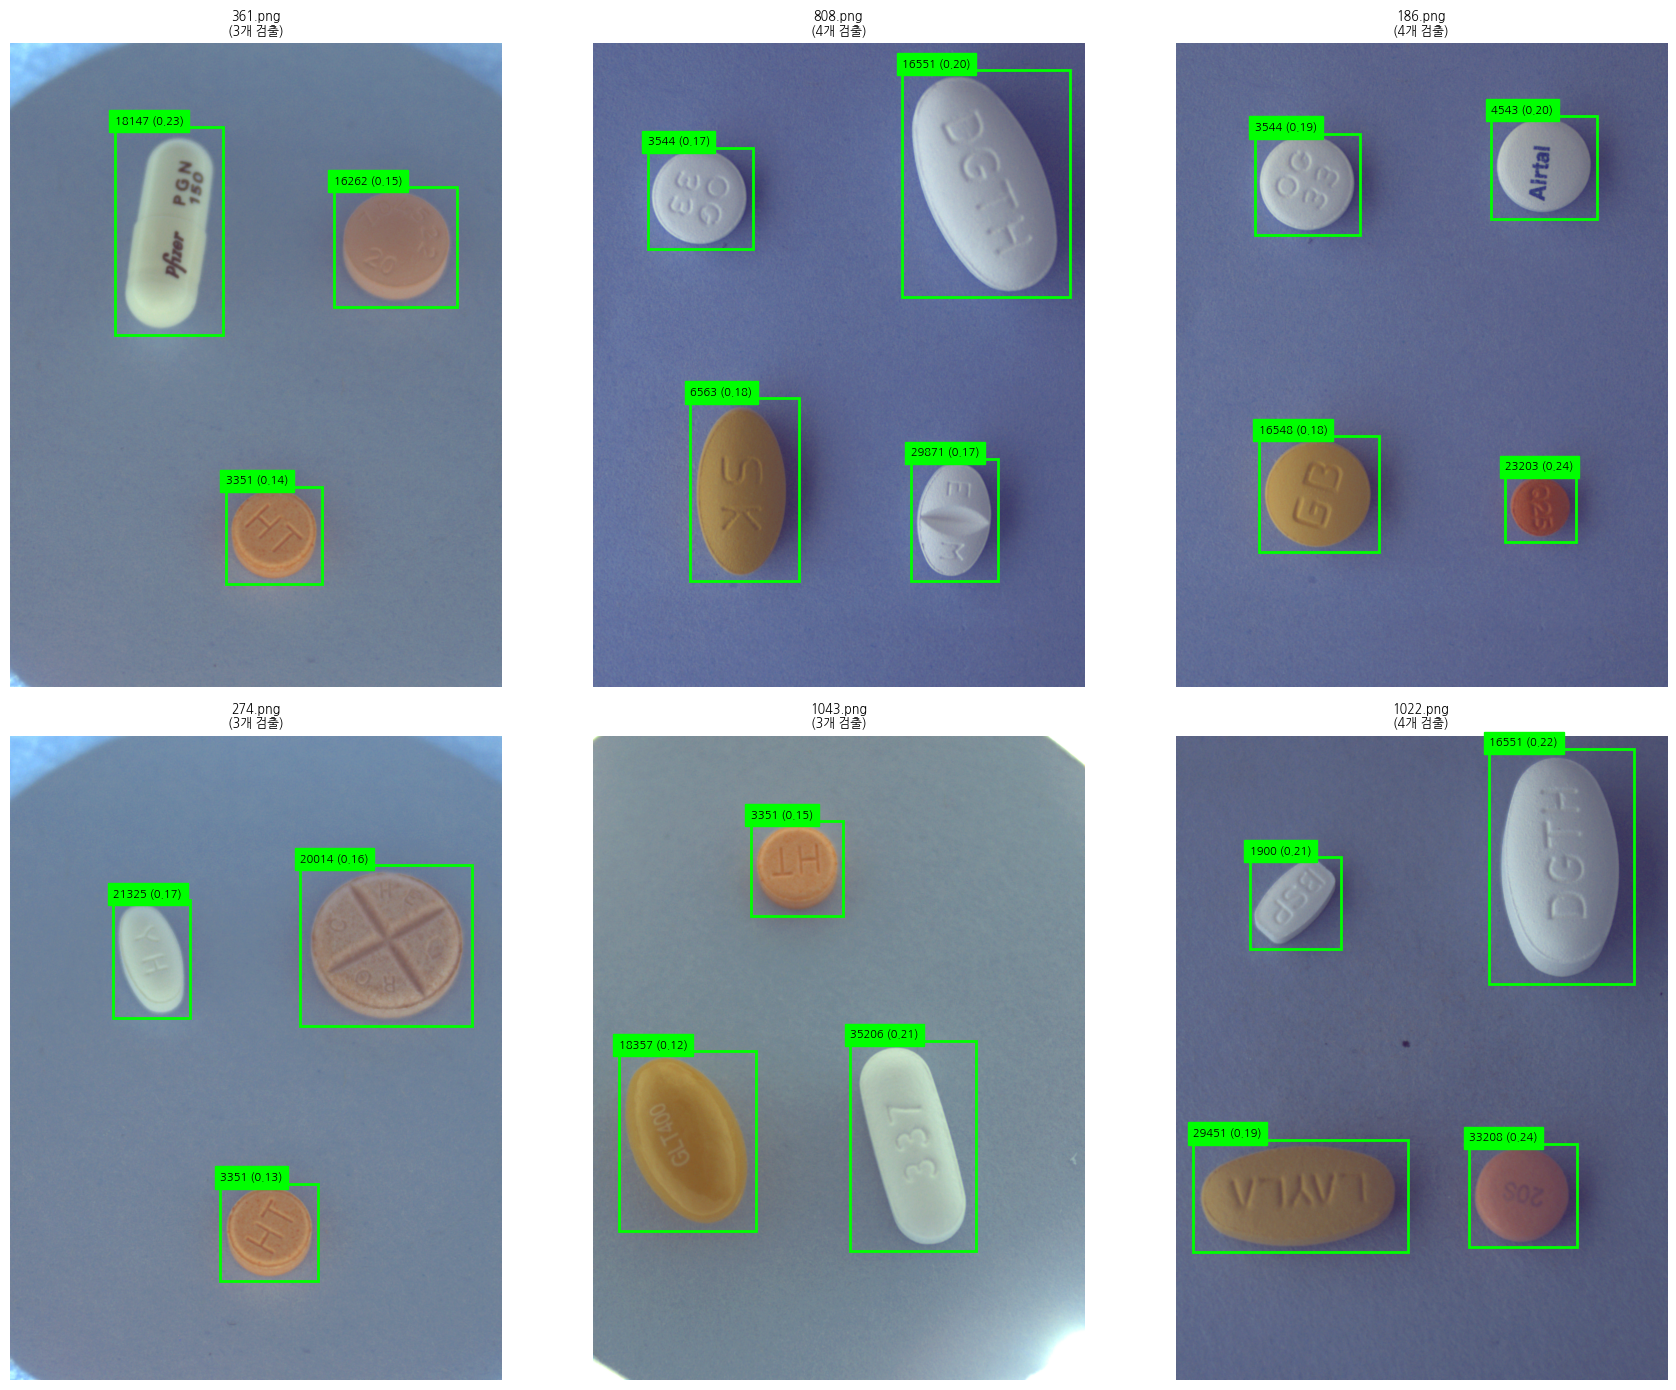

예측 중: 100%|██████████| 106/106 [03:38<00:00,  2.07s/it]


✅ 총 3180개 박스 예측 완료
✅ 이미지 842장 처리됨 (전체 842장)


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,16551,550,72,404,404,0.21
1,2,1,24850,175,742,177,290,0.18
2,3,1,1900,157,252,205,123,0.18
3,4,1,27926,599,674,255,481,0.17
4,5,10,1900,644,843,186,190,0.19


In [ ]:
import os
import math
import random
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

# ==========================================
# 1. 베스트 모델 + 프로세서 로드 (한 번만)
# ==========================================
model = RTDetrForObjectDetection.from_pretrained(
    DRIVE_SAVE_DIR,  # 기본 CHECKPOINT 대신 학습된 드라이브 경로에서 로드
    num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
).to(DEVICE)
model.eval()

image_processor = RTDetrImageProcessor.from_pretrained(CHECKPOINT)

# ⭐ 모델 인덱스(0~N-1) -> 원래 category_id로 되돌리는 매핑
# ⚠️ full_train_dataset이 아니라 train_dataset (현재 변수명)
idx2catid = {idx: cat_id for cat_id, idx in train_dataset.class_map.items()}

print("✅ 모델/프로세서 로드 완료")

# ==========================================
# 2. 테스트 이미지 목록
# ==========================================
test_image_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")])
print(f"테스트 이미지 개수: {len(test_image_files)}")
print(test_image_files[:5])


# ==========================================
# 3. 예측 시각화 (샘플 확인용)
# ==========================================
def visualize_predictions(num_samples=6, score_threshold=0.01, seed=None):
    model.eval()
    if seed is not None:
        random.seed(seed)

    sample_files = random.sample(test_image_files, num_samples)

    cols = 3
    rows = math.ceil(num_samples / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 7))
    axes = axes.flatten()

    with torch.no_grad():
        for i, fname in enumerate(sample_files):
            img = Image.open(os.path.join(TEST_IMG_DIR, fname)).convert("RGB")
            orig_size = (img.height, img.width)

            img_t = test_transform(img).unsqueeze(0).to(DEVICE)
            outputs = model(pixel_values=img_t)

            target_sizes = torch.tensor([orig_size]).to(DEVICE)
            result = image_processor.post_process_object_detection(
                outputs, threshold=score_threshold, target_sizes=target_sizes
            )[0]

            scores, labels, boxes = result["scores"], result["labels"], result["boxes"]
            if len(scores) > 4:
                top4_idx = torch.argsort(scores, descending=True)[:4]
                scores, labels, boxes = scores[top4_idx], labels[top4_idx], boxes[top4_idx]

            ax = axes[i]
            ax.imshow(img)
            ax.set_title(f"{fname}\n({len(scores)}개 검출)", fontsize=9)

            for score, label, box in zip(scores, labels, boxes):
                x1, y1, x2, y2 = box.tolist()
                w, h = x2 - x1, y2 - y1
                rect = patches.Rectangle((x1, y1), w, h, linewidth=2,
                                          edgecolor="lime", facecolor="none")
                ax.add_patch(rect)
                cat_id = idx2catid[label.item()]
                ax.text(x1, max(y1 - 5, 0), f"{cat_id} ({score:.2f})",
                         color="black", fontsize=8, backgroundcolor="lime")
            ax.axis("off")

    for j in range(num_samples, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(num_samples=6, score_threshold=0.1)


# ==========================================
# 4. 전체 테스트셋 예측 + submission.csv 생성
# ==========================================
SCORE_THRESHOLD = 0.1
BATCH_SIZE = 8

rows = []
annotation_id = 1

with torch.no_grad():
    for i in tqdm(range(0, len(test_image_files), BATCH_SIZE), desc="예측 중"):
        batch_files = test_image_files[i:i + BATCH_SIZE]
        batch_images = []
        orig_sizes = []

        for fname in batch_files:
            img = Image.open(os.path.join(TEST_IMG_DIR, fname)).convert("RGB")
            orig_sizes.append((img.height, img.width))
            img_t = test_transform(img)
            batch_images.append(img_t)

        pixel_values = torch.stack(batch_images).to(DEVICE)
        outputs = model(pixel_values=pixel_values)

        target_sizes = torch.tensor(orig_sizes).to(DEVICE)
        results = image_processor.post_process_object_detection(
            outputs, threshold=SCORE_THRESHOLD, target_sizes=target_sizes
        )

        for fname, result in zip(batch_files, results):
            image_id = os.path.splitext(fname)[0]

            scores = result["scores"]
            labels = result["labels"]
            boxes = result["boxes"]

            if len(scores) > 4:
                top4_idx = torch.argsort(scores, descending=True)[:4]
                scores = scores[top4_idx]
                labels = labels[top4_idx]
                boxes = boxes[top4_idx]

            for score, label, box in zip(scores, labels, boxes):
                x1, y1, x2, y2 = box.tolist()
                rows.append({
                    "annotation_id": annotation_id,
                    "image_id": image_id,
                    "category_id": idx2catid[label.item()],
                    "bbox_x": int(round(x1)),
                    "bbox_y": int(round(y1)),
                    "bbox_w": int(round(x2 - x1)),
                    "bbox_h": int(round(y2 - y1)),
                    "score": round(score.item(), 2),
                })
                annotation_id += 1


submission_df = pd.DataFrame(rows, columns=[
    "annotation_id", "image_id", "category_id",
    "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
])
submission_df.to_csv("submission.csv", index=False)

print(f"✅ 총 {len(submission_df)}개 박스 예측 완료")
print(f"✅ 이미지 {submission_df['image_id'].nunique()}장 처리됨 (전체 {len(test_image_files)}장)")
submission_df.head()

In [ ]:
missing = set(os.path.splitext(f)[0] for f in test_image_files) - set(submission_df["image_id"])
print(f"예측이 없는 이미지: {len(missing)}개 / 전체 {len(test_image_files)}장")

예측이 없는 이미지: 0개 / 전체 842장


In [ ]:
from google.colab import files
jc = 'submission.csv'
files.download(jc)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

로스가 제가 알던 방식이 아니라서 이미지를 띄어서 체크를 했는데 처음에 20에폭(0.42)은 몇개 못잡고 40에폭은 35부터 못내려가서 스케쥴럴를 넣었습니다(0.29)


CosineAnnealingLR 스케쥴러는 넣었는데 40에폭으로는 덜 내려가게 되어서 오히려 결과가 안좋아졌어요(0.31) 아에 에폭 기준 +15를 감안해서 내려가도록 설계해볼게요(0.29) 에폭을 60으로 늘립니

안 얼리고 했었던 거라 비교 하려해봤던거였어요20에폭(5.73) 이 모델의 문제는 이게 아니라는것을 깨닫고 전부 뜯어 고칩니다


일단 색깔 구분은 중요하기에 컬러지터를 제외시킵니다 원래 컬러지터,리사이즈, 플립만 적용했었어요

바뀐 점은 데이터가 부족하다고 판단되어 배경과 이미지를잘라서 이미지 자체를 증가 시킵니다 그리고 후보군 잡는 개수를 200->20으로 줄이고 kfold를 넣었습니

20에폭일때 로스가 6까지 내려갔고 제출시 0.95입니ㅏ그냥 40에폭 돌렸더니 로스가 이상하게 안내려가서 코사인 스케쥴러에서 바꿨습니다 스케쥴러 바꾼40은 5까지 내려가네요 60까지 늘리면 4 후반까지도 내려가요!

이미지로 뽑아보니 좀 작은 알약에 대해 잘 못 찾는 거 같아요 한번 후보군을 늘려볼게요 늘려보니 40에폭 만에 4후반을 가고 60에폭에서 4초반까지 가네요


많이 좋아졌는데 글씨가 잘 안보이는 알약에 대한 확신이 적네요 이제 이건 증강으로 해결해 볼게요